<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import sys
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import mlflow
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.experiment import log_metrics, log_params, measure_training_time, setup_experiment, start_run
from src.metrics import classification_metrics
from src.plots import compare_models
from src.utils import normalize_images, print_section, set_seed

In [4]:
EXPERIMENT_NAME = "assignment_mlp_fashion_mnist"
setup_experiment(EXPERIMENT_NAME)

2026/05/17 23:41:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/17 23:41:24 INFO mlflow.store.db.utils: Updating database tables
2026/05/17 23:41:26 INFO mlflow.tracking.fluent: Experiment with name 'assignment_mlp_fashion_mnist' does not exist. Creating a new experiment.


# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

Para MLPs, normalizar os dados é importante na prática. Como o treinamento depende de gradientes, entradas em escalas muito altas tendem a deixar a otimização mais instável, a desacelerar a convergência e a saturar ativações como `logistic` e `tanh`. No Fashion MNIST, dividir os pixels por 255 coloca as entradas no intervalo `[0, 1]`, o que torna o treino mais estável e a comparação entre hiperparâmetros mais justa.

In [5]:
@lru_cache(maxsize=1)
def _fashion_mnist_cache():
    dataset = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
    X = normalize_images(dataset.data.astype(np.float32))
    y = dataset.target.astype(np.int64)

    # Mantemos o split oficial 60k/10k e abrimos validacao apenas no conjunto de desenvolvimento.
    X_dev, X_test = X[:60000], X[60000:]
    y_dev, y_test = y[:60000], y[60000:]
    return X_dev, X_test, y_dev, y_test


def load_data(seed):
    set_seed(seed)
    X_dev, _, y_dev, _ = _fashion_mnist_cache()
    X_train, X_val, y_train, y_val = train_test_split(
        X_dev,
        y_dev,
        test_size=0.2,
        random_state=seed,
        stratify=y_dev,
    )
    return X_train, X_val, y_train, y_val


def load_test_data():
    _, X_test, _, y_test = _fashion_mnist_cache()
    return X_test, y_test


SEED = 42
X_train, X_val, y_train, y_val = load_data(SEED)
X_test, y_test = load_test_data()

print_section("Shapes")
print(f"Treino: {X_train.shape}")
print(f"Validacao: {X_val.shape}")
print(f"Teste: {X_test.shape}")
print(f"Intervalo normalizado: [{X_train.min():.3f}, {X_train.max():.3f}]")


Shapes
Treino: (48000, 784)
Validacao: (12000, 784)
Teste: (10000, 784)
Intervalo normalizado: [0.000, 1.000]


# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [6]:
DEFAULT_MAX_ITER = 20
DEFAULT_BATCH_SIZE = 256


def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=DEFAULT_MAX_ITER,
    batch_size=DEFAULT_BATCH_SIZE,
):
    set_seed(seed)
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=seed,
        solver="adam",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        verbose=False,
    )
    model.fit(X_train, y_train)
    return model


baseline_model = train_mlp(
    X_train,
    y_train,
    activation="relu",
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=SEED,
)
print(f"Epocas executadas pelo modelo-base: {baseline_model.n_iter_}")

Epocas executadas pelo modelo-base: 20


# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [7]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return classification_metrics(y_test, y_pred)


baseline_metrics = evaluate(baseline_model, X_val, y_val)
display(pd.DataFrame([baseline_metrics]).round(4))

,accuracy,precision,recall,f1_score
0,0.887,0.8866,0.887,0.8866


As métricas foram calculadas com média ponderada (`weighted`), o que mantém precisão, recall e F1 comparáveis entre experimentos mesmo quando as frequências observadas das classes variam ligeiramente entre os subconjuntos avaliados.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [8]:
def run_experiment(
    X_train,
    y_train,
    X_eval,
    y_eval,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    run_name=None,
    max_iter=DEFAULT_MAX_ITER,
    batch_size=DEFAULT_BATCH_SIZE,
):
    params = {
        "activation": activation,
        "hidden_layers": hidden_layers,
        "learning_rate": learning_rate,
        "max_iter": max_iter,
        "batch_size": batch_size,
    }

    if mlflow.active_run() is not None:
        mlflow.end_run()

    with start_run(run_name=run_name):
        model, training_time = measure_training_time(
            train_mlp,
            X_train,
            y_train,
            activation,
            hidden_layers,
            learning_rate,
            seed,
            max_iter=max_iter,
            batch_size=batch_size,
        )
        metrics = evaluate(model, X_eval, y_eval)
        metrics["training_time"] = training_time

        log_params(params)
        log_metrics(metrics)

    return {
        "model": model,
        "params": params,
        "metrics": metrics,
        "train_accuracy": model.score(X_train, y_train),
    }


def build_result_row(label, experiment):
    row = {
        "label": label,
        **experiment["params"],
        **experiment["metrics"],
        "train_accuracy": experiment["train_accuracy"],
        "generalization_gap": experiment["train_accuracy"] - experiment["metrics"]["accuracy"],
        "epochs": experiment["model"].n_iter_,
    }
    return row


baseline_run = run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    activation="relu",
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=SEED,
    run_name="baseline_relu_64",
)
display(pd.DataFrame([build_result_row("baseline", baseline_run)]).round(4))

,label,activation,hidden_layers,learning_rate,max_iter,batch_size,accuracy,precision,recall,f1_score,training_time,train_accuracy,generalization_gap,epochs
0,baseline,relu,"(64,)",0.001,20,256,0.887,0.8866,0.887,0.8866,66.2225,0.8981,0.0111,20


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

,label,activation,hidden_layers,learning_rate,max_iter,batch_size,accuracy,precision,recall,f1_score,training_time,train_accuracy,generalization_gap,epochs
0,relu,relu,"(64,)",0.001,20,256,0.8870,0.8866,0.8870,0.8866,41.4318,0.8981,0.0111,20
1,tanh,tanh,"(64,)",0.001,20,256,0.8846,0.8855,0.8846,0.8848,25.4726,0.9002,0.0156,20
2,logistic,logistic,"(64,)",0.001,20,256,0.8779,0.8803,0.8779,0.8784,49.6949,0.8871,0.0092,20


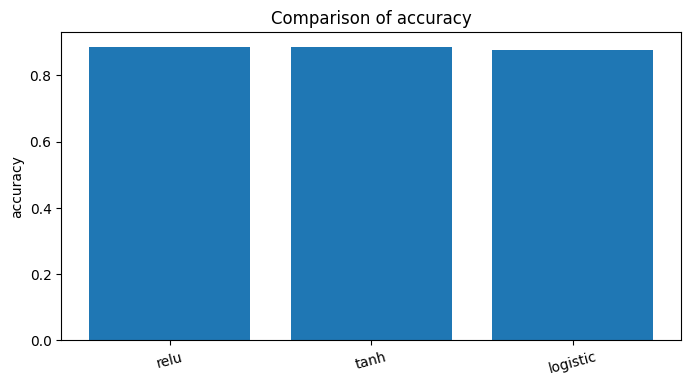

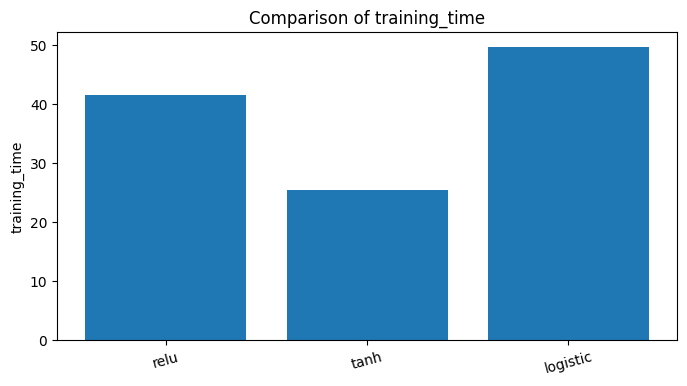

Melhor ativacao na validacao: relu


In [9]:
activation_candidates = ["logistic", "tanh", "relu"]
activation_results = []

for activation in activation_candidates:
    experiment = run_experiment(
        X_train,
        y_train,
        X_val,
        y_val,
        activation=activation,
        hidden_layers=(64,),
        learning_rate=0.001,
        seed=SEED,
        run_name=f"activation_{activation}",
    )
    activation_results.append(build_result_row(activation, experiment))

activation_results_df = (
    pd.DataFrame(activation_results)
    .sort_values(["accuracy", "f1_score"], ascending=False)
    .reset_index(drop=True)
)

display(activation_results_df.round(4))
compare_models(activation_results_df["label"], activation_results_df["accuracy"], "accuracy")
compare_models(activation_results_df["label"], activation_results_df["training_time"], "training_time")

best_activation = activation_results_df.loc[0, "activation"]
print(f"Melhor ativacao na validacao: {best_activation}")

## Responda:
- **Melhor convergência:** `relu`, com a melhor accuracy de validação (`0.8870`) e o melhor F1 (`0.8866`).
- **Maior estabilidade:** considerando desempenho e gap de generalização, `relu` foi a mais equilibrada. A `logistic` teve gap um pouco menor (`0.0092`), mas ficou claramente atrás em desempenho.
- **Diferenças significativas de treinamento:** sim. `tanh` foi a mais rápida (`~25.5 s`), `relu` ficou em nível intermediário (`~41.4 s`) e `logistic` foi a mais lenta (`~49.7 s`).

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

,label,activation,hidden_layers,learning_rate,max_iter,batch_size,accuracy,precision,recall,f1_score,training_time,train_accuracy,generalization_gap,epochs
0,"(256, 128)",relu,"(256, 128)",0.001,20,256,0.8967,0.8978,0.8967,0.8971,132.6560,0.9289,0.0322,20
1,"(128, 64)",relu,"(128, 64)",0.001,20,256,0.8896,0.8937,0.8896,0.8903,78.1861,0.9176,0.0281,20
2,"(64,)",relu,"(64,)",0.001,20,256,0.8870,0.8866,0.8870,0.8866,47.5302,0.8981,0.0111,20
3,"(32,)",relu,"(32,)",0.001,20,256,0.8802,0.8797,0.8802,0.8792,42.7795,0.8889,0.0086,20


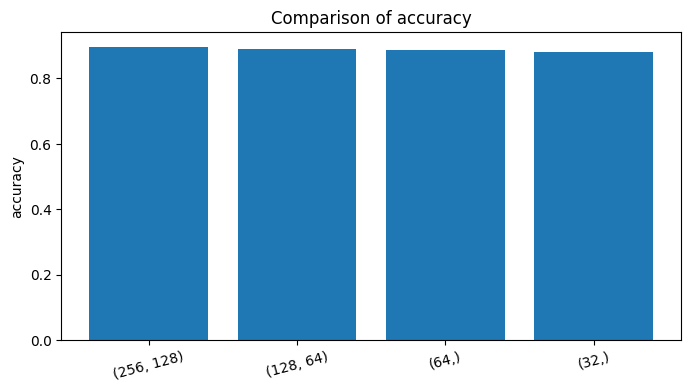

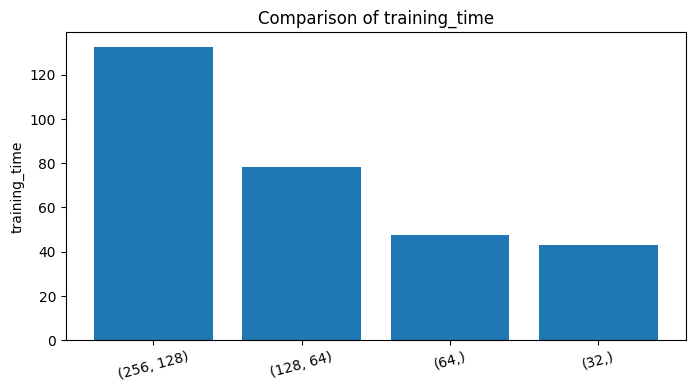

Melhor arquitetura na validacao: (256, 128)


In [10]:
architecture_candidates = [(32,), (64,), (128, 64), (256, 128)]
architecture_results = []

for hidden_layers in architecture_candidates:
    experiment = run_experiment(
        X_train,
        y_train,
        X_val,
        y_val,
        activation=best_activation,
        hidden_layers=hidden_layers,
        learning_rate=0.001,
        seed=SEED,
        run_name=f"architecture_{str(hidden_layers).replace(' ', '')}",
    )
    architecture_results.append(build_result_row(str(hidden_layers), experiment))

architecture_results_df = (
    pd.DataFrame(architecture_results)
    .sort_values(["accuracy", "f1_score"], ascending=False)
    .reset_index(drop=True)
)

display(architecture_results_df.round(4))
compare_models(architecture_results_df["label"], architecture_results_df["accuracy"], "accuracy")
compare_models(architecture_results_df["label"], architecture_results_df["training_time"], "training_time")

best_architecture = architecture_results_df.loc[0, "hidden_layers"]
print(f"Melhor arquitetura na validacao: {best_architecture}")

## Responda:

- **Redes maiores sempre melhoraram os resultados?** Elas melhoraram a accuracy de validação, mas o ganho não foi proporcional ao custo. A passagem de `(64,)` para `(256, 128)` elevou a accuracy de `0.8870` para `0.8967`, enquanto o tempo de treino quase triplicou.
- **Redes maiores sempre melhoraram os resultados?** Apenas em accuracy. Em generalização, o gap cresceu de `0.0111` em `(64,)` para `0.0322` em `(256, 128)`, indicando maior tendência a overfitting.
- **Qual arquitetura apresentou melhor tradeoff?** `(64,)`, porque manteve boa accuracy (`0.8870`), treinou bem mais rápido que as arquiteturas profundas e apresentou o melhor equilíbrio entre custo computacional e generalização.

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

,label,activation,hidden_layers,learning_rate,max_iter,batch_size,accuracy,precision,recall,f1_score,training_time,train_accuracy,generalization_gap,epochs
0,0.001,relu,"(256, 128)",0.001,20,256,0.8967,0.8978,0.8967,0.8971,115.8343,0.9289,0.0322,20
1,0.01,relu,"(256, 128)",0.010,20,256,0.8858,0.8861,0.8858,0.8850,183.1112,0.9125,0.0266,20
2,0.1,relu,"(256, 128)",0.100,20,256,0.8230,0.8275,0.8230,0.8235,172.9831,0.8286,0.0056,17


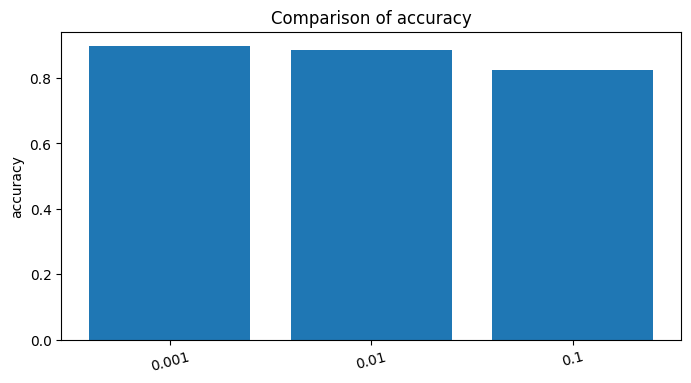

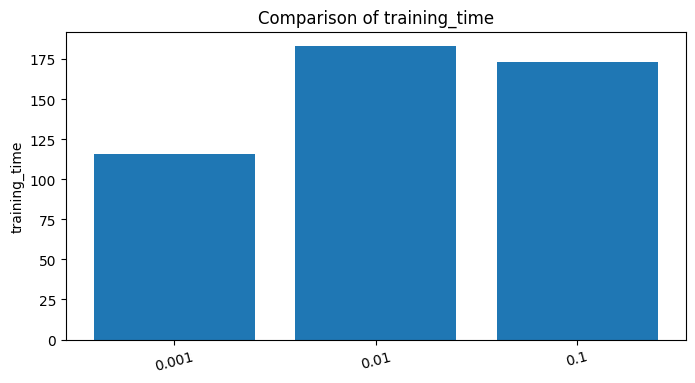

Melhor learning rate na validacao: 0.001

Melhor configuracao avaliada no conjunto de teste


,label,activation,hidden_layers,learning_rate,max_iter,batch_size,accuracy,precision,recall,f1_score,training_time,train_accuracy,generalization_gap,epochs
0,best_on_test,relu,"(256, 128)",0.001,20,256,0.8872,0.8894,0.8872,0.887,105.4026,0.9273,0.0401,20


In [11]:
learning_rate_candidates = [0.1, 0.01, 0.001]
learning_rate_results = []

for learning_rate in learning_rate_candidates:
    experiment = run_experiment(
        X_train,
        y_train,
        X_val,
        y_val,
        activation=best_activation,
        hidden_layers=best_architecture,
        learning_rate=learning_rate,
        seed=SEED,
        run_name=f"lr_{learning_rate}",
    )
    learning_rate_results.append(build_result_row(str(learning_rate), experiment))

learning_rate_results_df = (
    pd.DataFrame(learning_rate_results)
    .sort_values(["accuracy", "f1_score"], ascending=False)
    .reset_index(drop=True)
)

display(learning_rate_results_df.round(4))
compare_models(learning_rate_results_df["label"], learning_rate_results_df["accuracy"], "accuracy")
compare_models(learning_rate_results_df["label"], learning_rate_results_df["training_time"], "training_time")

best_learning_rate = float(learning_rate_results_df.loc[0, "learning_rate"])
print(f"Melhor learning rate na validacao: {best_learning_rate}")

X_dev = np.vstack([X_train, X_val])
y_dev = np.concatenate([y_train, y_val])
final_test_run = run_experiment(
    X_dev,
    y_dev,
    X_test,
    y_test,
    activation=best_activation,
    hidden_layers=best_architecture,
    learning_rate=best_learning_rate,
    seed=SEED,
    run_name="best_configuration_test",
)

final_test_results_df = pd.DataFrame([build_result_row("best_on_test", final_test_run)])
print_section("Melhor configuracao avaliada no conjunto de teste")
display(final_test_results_df.round(4))

## Responda:
- **O treinamento ficou instável?** Para `0.1`, sim. A accuracy caiu para `0.8230`, bem abaixo dos demais cenários, sugerindo passos grandes demais na otimização.
- **Houve dificuldade de convergência?** Sim, principalmente para `0.1` e `0.01`. Nenhum deles superou `0.001`, e `0.01` ainda exigiu o maior tempo de treino (`~183.1 s`) sem compensar em desempenho.
- **Qual learning rate apresentou melhor comportamento?** `0.001`, com a melhor accuracy de validação (`0.8967`), o melhor F1 (`0.8971`) e o menor tempo de treino entre os três valores testados.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


- **Melhor ativação:** `relu`.
- **Arquitetura com melhor tradeoff:** `(64,)`, porque preservou boa accuracy com custo computacional e gap de generalização bem menores.
- **Learning rate mais estável:** `0.001`.
- **Houve overfitting?** Sim, de forma moderada, principalmente nas arquiteturas maiores. O melhor modelo em validação (`(256, 128)`) terminou com gap de generalização de `0.0322` na validação e `0.0401` no teste.
- **Melhor configuração final:** `activation="relu"`, `hidden_layers=(256, 128)`, `learning_rate=0.001`, `max_iter=20` e `batch_size=256`. No conjunto de teste, ela obteve `accuracy=0.8872`, `precision=0.8894`, `recall=0.8872` e `f1_score=0.8870`.
- **Principais dificuldades observadas:** o custo de treinamento cresceu rapidamente com arquiteturas maiores, e learning rates altos degradaram bastante o desempenho em vez de acelerar a convergência.